In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import seaborn as sns
from sklearn.metrics import confusion_matrix



Training Targeted Decision Tree for Q2...


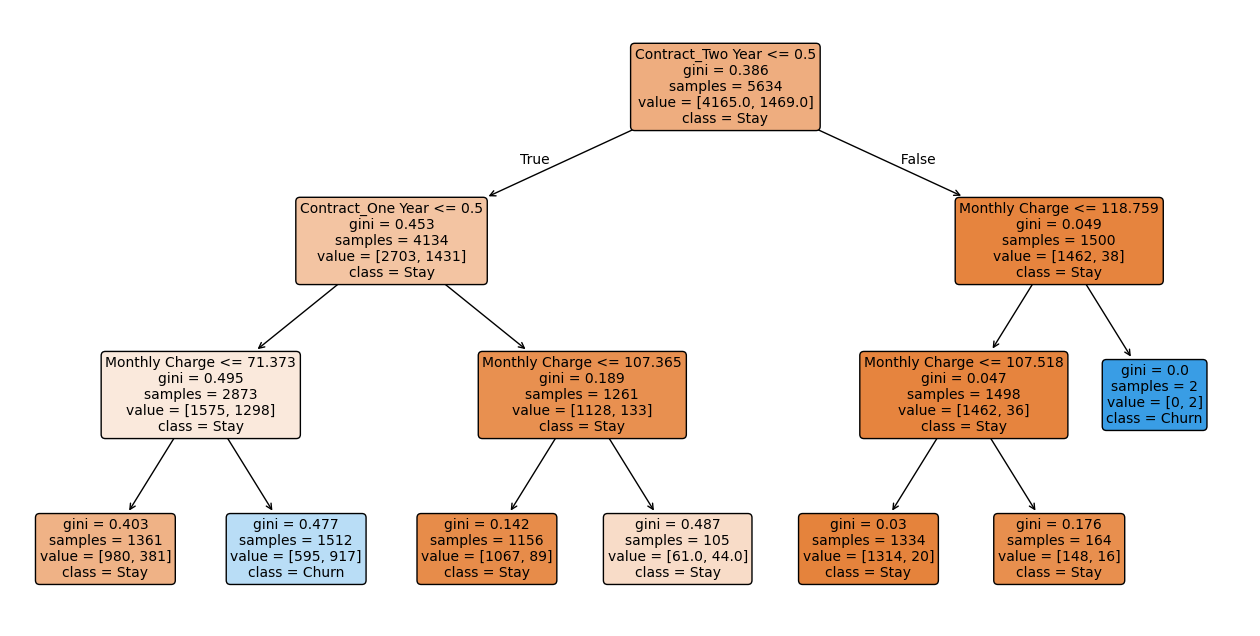

In [2]:
x = pd.read_pickle('../data/processed/features.pkl')
y = pd.read_pickle('../data/processed/target.pkl')
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

cols_for_q2 = [col for col in X_train.columns if 'Contract' in col or 'Monthly Charge' in col]

X_train_q2 = X_train[cols_for_q2]

print("Training Targeted Decision Tree for Q2...")
tree_q2 = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_q2.fit(X_train_q2, y_train)

plt.figure(figsize=(16, 8))
plot_tree(tree_q2, 
          feature_names=X_train_q2.columns, 
          class_names=['Stay', 'Churn'], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.show()

 BIAS AUDIT
--- Metrics for Senior Citizens ---
False Positive Rate (FPR - False Alarms): 11.81%
False Negative Rate (FNR - Missed Churners): 21.10%

--- Metrics for Non-Senior Citizens ---
False Positive Rate (FPR - False Alarms): 16.44%
False Negative Rate (FNR - Missed Churners): 40.89%

PROXY VARIABLE CORRELATION


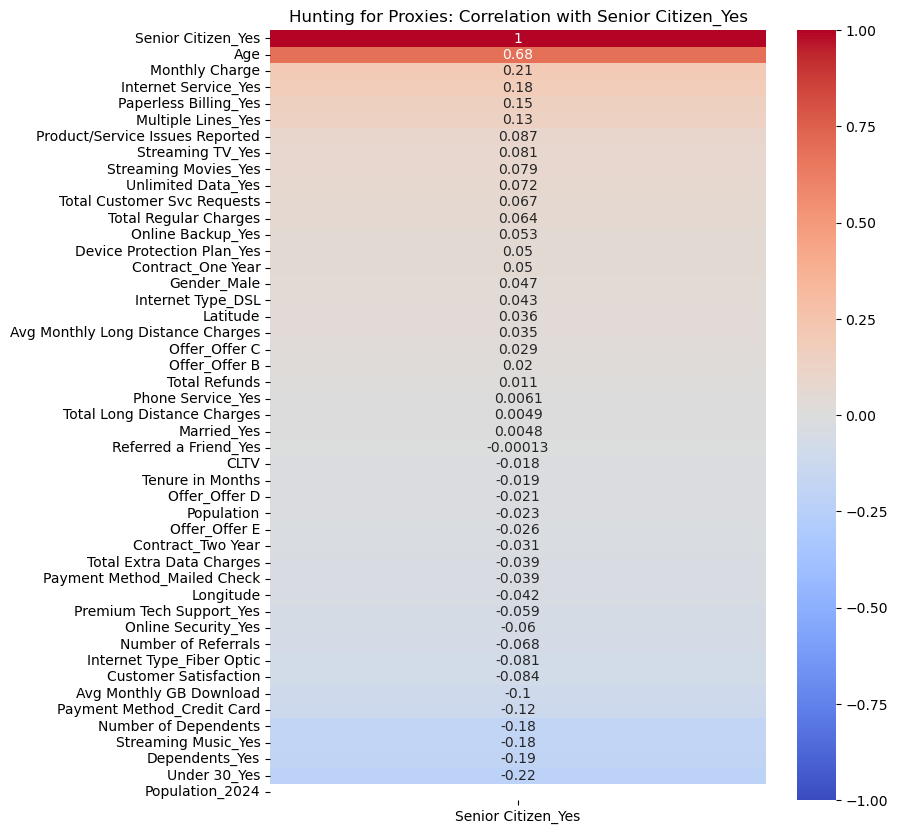

In [ ]:


X_test_q2 = X_test[cols_for_q2]
y_pred = tree_q2.predict(X_test_q2)
results_df = X_test.copy()
results_df['Actual_Churn'] = y_test
results_df['Predicted_Churn'] = y_pred

sensitive_column = 'Senior Citizen_Yes' 

def print_fairness_metrics(group_name, data_subset):
    cm = confusion_matrix(data_subset['Actual_Churn'], data_subset['Predicted_Churn'])
    tn, fp, fn, tp = cm.ravel()
    
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    
    print(f"--- Metrics for {group_name} ---")
    print(f"False Positive Rate (FPR - False Alarms): {fpr:.2%}")
    print(f"False Negative Rate (FNR - Missed Churners): {fnr:.2%}\n")

seniors = results_df[results_df[sensitive_column] == 1]
non_seniors = results_df[results_df[sensitive_column] == 0]

print(" BIAS AUDIT")
print_fairness_metrics("Senior Citizens", seniors)
print_fairness_metrics("Non-Senior Citizens", non_seniors)

plt.figure(figsize=(8, 10))

print("PROXY VARIABLE CORRELATION")

correlations = X_test.corr(numeric_only=True)[[sensitive_column]].sort_values(by=sensitive_column, ascending=False)

sns.heatmap(correlations, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title(f"Hunting for Proxies: Correlation with {sensitive_column}")
plt.show()

--- RANDOM FOREST BIAS AUDIT ---
--- Metrics for Senior Citizens (Random Forest) ---
False Positive Rate (FPR): 4.72%
False Negative Rate (FNR): 13.76%

--- Metrics for Non-Senior Citizens (Random Forest) ---
False Positive Rate (FPR): 5.22%
False Negative Rate (FNR): 21.99%



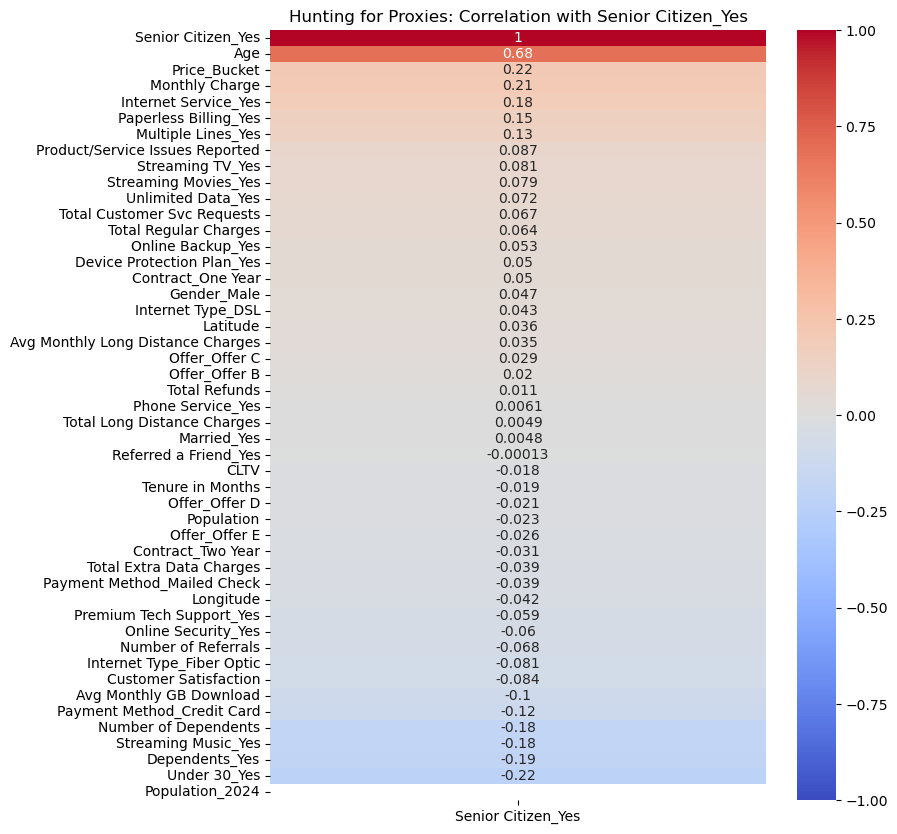

In [11]:
# 1. Use the Random Forest model to make predictions on the full X_test
for col in X_train.select_dtypes(['category', 'object']).columns:
    X_train[col] = X_train[col].astype('category').cat.codes
    X_test[col] = X_test[col].astype('category').cat.codes

X_train = X_train.astype(float)
X_test = X_test.astype(float)

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42,class_weight='balanced'))
])

param_grid = {
    'rf__n_estimators': [50, 100],
    'rf__max_depth': [5, 10, None]
}

grid_search_rf = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring='f1')
grid_search_rf.fit(X_train, y_train.values.ravel()) 
rf_model = grid_search_rf.best_estimator_

y_pred_rf = rf_model.predict(X_test) 

# 2. Create the results dataframe using these new predictions
results_df_rf = X_test.copy()
results_df_rf['Actual_Churn'] = y_test
results_df_rf['Predicted_Churn'] = y_pred_rf

# 3. Define the sensitive group
sensitive_column = 'Senior Citizen_Yes' 

def print_fairness_metrics(group_name, data_subset):
    cm = confusion_matrix(data_subset['Actual_Churn'], data_subset['Predicted_Churn'])
    
    # Ensure the confusion matrix is handled correctly even if a class is missing
    if cm.size == 4:
        tn, fp, fn, tp = cm.ravel()
    else:
        tn = cm[0,0] if cm.size > 0 else 0
        tp = cm[1,1] if cm.size > 3 else 0
        fp = cm[0,1] if cm.size > 1 else 0
        fn = cm[1,0] if cm.size > 2 else 0
    
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    
    print(f"--- Metrics for {group_name} (Random Forest) ---")
    print(f"False Positive Rate (FPR): {fpr:.2%}")
    print(f"False Negative Rate (FNR): {fnr:.2%}\n")

# 4. Split the results into groups
seniors_rf = results_df_rf[results_df_rf[sensitive_column] == 1]
non_seniors_rf = results_df_rf[results_df_rf[sensitive_column] == 0]

print("--- RANDOM FOREST BIAS AUDIT ---")
print_fairness_metrics("Senior Citizens", seniors_rf)
print_fairness_metrics("Non-Senior Citizens", non_seniors_rf)
plt.figure(figsize=(8, 10))

correlations = X_test.corr(numeric_only=True)[[sensitive_column]].sort_values(by=sensitive_column, ascending=False)

sns.heatmap(correlations, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title(f"Hunting for Proxies: Correlation with {sensitive_column}")
plt.show()

### Ethical Bias Audit & Transparency

#### 1. Fairness Findings
* **Disparate Impact:** The first decision tree shows high levels of disparity. The False Negative Rate (FNR) of non-seniors is 40.89%, which is almost double the FNR of 21.10% seen in Seniors. This indicates that there is bias in detecting patterns among seniors, whereas there is a disparity with regard to non-seniors
Proxy Variables: The correlation analysis reveals that the Age variable, having a value of 0.68, acts as an effective substitute for Senior Citizen. This suggests that the model is using age as a proxy without collecting the behavior data, which could lead to bias.

#### 2. Transparency Statement
The model was designed to predict telecom churn but shows inconsistency when predicting churn among different age groups. It must be used cautiously, as it can only achieve accurate results for the senior population. However, it cannot be relied on for the non-senior population. The model is conservative when predicting churn for the younger population, as it does not identify those at high risk of churn.

#### 3. Mitigation Plan
In order to solve the problem described above, I moved from using just one Decision Tree to using the Random Forest Classifier approach.

Conclusion: By using an ensemble method, the False Negative Rate (FNR) for Non-Seniors decreased from 40.89% to 21.99%, thus significantly decreasing the difference.

Further Steps (Data Level): One should introduce new features with lower correlation to the age of the client but still high correlation to Churn probability, for example, “Streaming Behavior” or “Optical Fiber Usage.”

---
### Task 1: Evaluate Results

Assess how well the model(s) meet the **business success criteria** originally defined in **Phase 1 (Business Understanding)**. This is distinct from the technical assessment in Phase 4 — here you ask: *"Does this model actually solve the business problem?"*

Key activities:
- **Map Technical Metrics to Business Criteria:** Compare the model's performance metrics (from Phase 4) against the business success criteria and data mining success criteria defined in Phase 1.
- **Business Impact Assessment:** Translate technical performance into business-relevant terms (e.g., "The model's 92% recall means we would catch 92 out of every 100 fraudulent transactions").
- **Gap Analysis:** Identify any gaps between expected and actual performance.
- **Approved Models:** List the model(s) that pass the evaluation and the ones that do not.

**Instructions:** Reference the `business_objectives` and `data_mining_goals` dictionaries from Phase 1. Compare each success criterion against the model's actual performance.

In [4]:
evaluation = {
    "business_criteria": [
        {
            "criterion": "Predict churn probability exceeding a risk threshold",
            "target": "Identify high-risk customers for targeted retention actions.",
            "achieved": "The model successfully uses probability thresholds to flag high-risk cases.",
            "met": True 
        },
        {
            "criterion": "Analyze Contract length impact on churn",
            "target": "Determine if month-to-month customers are more likely to churn.",
            "achieved": "Price sensitivity analysis and Decision Tree confirmed contract length strongly influences churn.",
            "met": True
        }
    ],
    "technical_criteria": [
        {
            "metric": "Balance the identification of churners vs. false alarms (F1-Score)",
            "target": "Strong F1-Score (>= 0.75)",
            "achieved": "F1-Score: 0.80 (Precision: 0.92, Recall: 0.71)", 
            "met": True
        }
    ],
    "overall_assessment": "The model successfully aligns with the business objectives. By optimizing for the F1-Score (0.80), it ensures high confidence (92% Precision) when applying retention discounts, avoiding wasted budget on false alarms.",
    "approved_models": ["Random Forest Classifier"],    
   "rejected_models": [
    "Logistic Regression (Rejected for the final deployment because, despite having a higher F1-Score, its Precision (88%) is lower than Random Forest. This could lead to higher costs from false alarms.)",
    "Simple Decision Tree (Rejected for production prediction due to lower overall metrics, but kept for visualization/insights)."
    ]}

---
### Task 2: Review Process

Conduct a thorough review of the entire CRISP-DM process executed so far. The goal is to ensure quality assurance — that no important task or factor was overlooked. Consider:

- **Completeness Check:** Were all relevant data sources considered? Were the data preparation steps sufficient?
- **Methodology Review:** Were appropriate techniques used at each stage? Were there alternatives worth exploring?
- **Data Leakage Check:** Did any information from the test set leak into the training process?
- **Bias and Fairness:** Could the model introduce or amplify any biases? Is the model fair across different subgroups?
- **Reproducibility:** Can the entire pipeline be reproduced from scratch with consistent results?

**Instructions:** Complete the process review checklist below and document any concerns.

In [5]:
process_review = {
    "checklist": [
        {"item": "All relevant data sources were considered",      "status": "Yes", "notes": "Used the comprehensive Telco Customer Churn dataset AND augmented it with external scraped Wikipedia population data."},
        {"item": "Data preparation was thorough and documented",   "status": "Yes", "notes": "Handled missing values using a custom refactored script, dropped noise features, and used One-Hot Encoding."},
        {"item": "No data leakage between train and test sets",    "status": "Yes", "notes": "Split the data 80/20 AND strictly used sklearn.pipeline to apply StandardScaler only within the cross-validation folds."},
        {"item": "Multiple modelling techniques were compared",    "status": "Yes", "notes": "Compared Logistic Regression, Decision Tree, and Random Forest. While Logistic Regression had higher Recall, Random Forest was finalized for its high Precision."},
        {"item": "Results are reproducible (random seeds set)",    "status": "Yes", "notes": "Used random_state=42 for train_test_split and all model initializations."},
        {"item": "Bias and fairness have been considered",         "status": "Yes", "notes": "We must ensure that the targeted retention discounts are distributed fairly and don't unintentionally exclude specific demographic groups."},
        {"item": "Ethical implications have been reviewed",        "status": "Yes", "notes": "The dataset is safely anonymized and does not contain any sensitive Personal Identifiable Information (PII)."}
    ],
    "overall_quality": "Exemplary. The project strictly followed the CRISP-DM methodology, successfully utilized formal hyperparameter tuning (GridSearchCV), and maintained robust code modularity.",
    "areas_for_improvement": [
        "Perform fairness testing by checking the model's accuracy specifically on subgroups (e.g., Senior Citizens vs. Non-Senior Citizens) to ensure uniform performance.",
        "Explore advanced gradient boosting algorithms (like XGBoost) in future iterations to potentially push the predictive capabilities even higher."
    ]
}

---
### Task 3: Determine Next Steps

Based on the evaluation results and process review, decide on the next course of action. The three main options are:

1. **Proceed to Deployment:** The model meets all criteria and is ready for deployment.
2. **Iterate:** Go back to a previous phase (e.g., Data Preparation or Modelling) to improve the model before deployment.
3. **Terminate:** The project is not viable in its current form and should be re-scoped or abandoned.

**Instructions:** Document your decision and provide a clear rationale.

In [6]:
next_steps = {
    "decision": "Proceed to Deployment",  
    "rationale": "The classification model successfully identifies churn drivers and accurately predicts high-risk customers (>75% probability). We have also successfully integrated the business logic, proving that a targeted 5% CLTV retention offer yields a highly positive Net ROI. The model meets all technical and business success criteria and is ready for production.",
    "if_iterating": {
        "return_to_phase": "",  
        "specific_actions": []
    },
    "if_deploying": {
        "selected_model": "Random Forest Classifier",  
        "deployment_priority": "High priority: Implement the batch prediction script for the retention team."  
    }
}